## Schizophrenia Symptoms

In [61]:
# import important libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import seaborn as sns

### 1. Load the dataset

In [62]:
df = pd.read_csv("../data/SchizophreniaSymptomnsData.csv")

df.head()

,Name,Age,Gender,Marital_Status,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
0,Leslie Goodwin,68,Female,Single,0.698075,0.123064,0.375303,0.234639,0.251869,Elevated Proneness
1,Dr. Troy Castaneda,88,Male,Married,0.049245,-0.042080,0.432807,0.501238,0.379948,Moderate Proneness
2,Chelsey Allen,67,Female,Married,0.651995,0.187117,NaN,0.301942,0.302588,Elevated Proneness
3,Dr. Devin Skinner DVM,95,Female,Widowed,0.036324,0.580808,0.005356,0.306968,0.813618,Moderate Proneness
4,Megan Mendez,81,Female,Widowed,0.926727,0.484202,0.702405,0.736054,0.579448,High Proneness


### 2. Inspect the data

1. `Name` is irrelvant for the prediction, it needs to be removed.
2. `Age` might be an important factor in the prediction of the model. `StandardScaler` will be needed as the values of the age are quit big compared to `fatigue`, `slowing`, `pain`, `hygiene`, `movement`.
3. `Gender` & `Material_Status` are both `str`, therefore OneHotEncoder will need to be used to turn into either binary or multi-class encoders.\
4. `Schizophrenia` is the predicted attributed. 

About the missing values there are two ways of dealing with them:
1. Use an Imputer to refill the values of the missing attr values.
2. Or remove these samples completely.
We have an average of 237 values in this dataset, I will resume with the first options as i prefer not removing this much data.

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            5000 non-null   str    
 1   Age             5000 non-null   int64  
 2   Gender          5000 non-null   str    
 3   Marital_Status  5000 non-null   str    
 4   Fatigue         4756 non-null   float64
 5   Slowing         4771 non-null   float64
 6   Pain            4758 non-null   float64
 7   Hygiene         5000 non-null   float64
 8   Movement        5000 non-null   float64
 9   Schizophrenia   5000 non-null   str    
dtypes: float64(5), int64(1), str(4)
memory usage: 390.8 KB


## 3. Explore the data EDA

This will include include forming an interest in the dataset.

1. multi-class matirial-status single, married, widowed.
2. Check missing values (already done).
3. With values we can check `age` validity.
4. Checking highest age. **Result:** the highest age is 95, which is normal, plotting will determine if it is a outlier or not.
5. Check `Name` attr for any duplicates.
6. Check the number female and male in this dataset

In [64]:
df.head()

,Name,Age,Gender,Marital_Status,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
0,Leslie Goodwin,68,Female,Single,0.698075,0.123064,0.375303,0.234639,0.251869,Elevated Proneness
1,Dr. Troy Castaneda,88,Male,Married,0.049245,-0.042080,0.432807,0.501238,0.379948,Moderate Proneness
2,Chelsey Allen,67,Female,Married,0.651995,0.187117,NaN,0.301942,0.302588,Elevated Proneness
3,Dr. Devin Skinner DVM,95,Female,Widowed,0.036324,0.580808,0.005356,0.306968,0.813618,Moderate Proneness
4,Megan Mendez,81,Female,Widowed,0.926727,0.484202,0.702405,0.736054,0.579448,High Proneness


In [65]:
df.tail()

,Name,Age,Gender,Marital_Status,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
4995,Anna Blevins,61,Female,Single,0.933016,0.505532,1.010435,0.868590,0.552105,High Proneness
4996,Robert Frazier,60,Female,Single,0.260125,0.625811,-0.076161,0.079046,0.593206,Moderate Proneness
4997,Louis Flores,62,Male,Married,0.248583,NaN,0.596990,0.119659,0.782998,Moderate Proneness
4998,Julie Nguyen,76,Female,Widowed,0.265702,0.525682,0.546284,0.402468,0.222236,Moderate Proneness
4999,Krista Cunningham,59,Male,Married,0.489590,0.630955,0.128390,0.552271,0.580275,Elevated Proneness


In [66]:
df.sample()

,Name,Age,Gender,Marital_Status,Fatigue,Slowing,Pain,Hygiene,Movement,Schizophrenia
1769,Michael Smith,80,Female,Divorced,0.947692,0.699002,0.242768,0.302673,0.926203,High Proneness


In [67]:
df.describe()

,Age,Fatigue,Slowing,Pain,Hygiene,Movement
count,5000.00000,4756.000000,4771.000000,4758.000000,5000.000000,5000.000000
mean,74.83340,0.503835,0.499524,0.499612,0.499717,0.499952
std,9.57787,0.296123,0.295365,0.294886,0.294907,0.289860
min,55.00000,-0.095115,-0.094843,-0.095771,-0.094284,-0.089272
25%,67.00000,0.247056,0.245795,0.251174,0.248998,0.254143
50%,75.00000,0.506278,0.502403,0.498051,0.501223,0.503340
75%,83.00000,0.759499,0.744812,0.749946,0.751029,0.741253
max,95.00000,1.091136,1.092146,1.090027,1.086922,1.088914


In [68]:
df[df["Age"] <= 0].values

array([], shape=(0, 10), dtype=object)

In [69]:
df["Age"].max()

np.int64(95)

In [70]:
df["Name"].duplicated().count()
# duplicated gives false values so there are no duplication
print(f"unique values: {df["Name"].duplicated().sum()}")
# df[df["Name"].duplicated(keep=False)]}

unique values: 159


In [71]:
print(f"The number of Females is {(df['Gender'] == "Female").sum()}")
print(f"The number of Males is {(df['Gender'] == "Male").sum()}")

The number of Females is 2510
The number of Males is 2490


## 4. Visualize the data

We need to categorize the the data and put the numbers together so we can plot them.

1. We can definitely make a boxplot for `Age`.

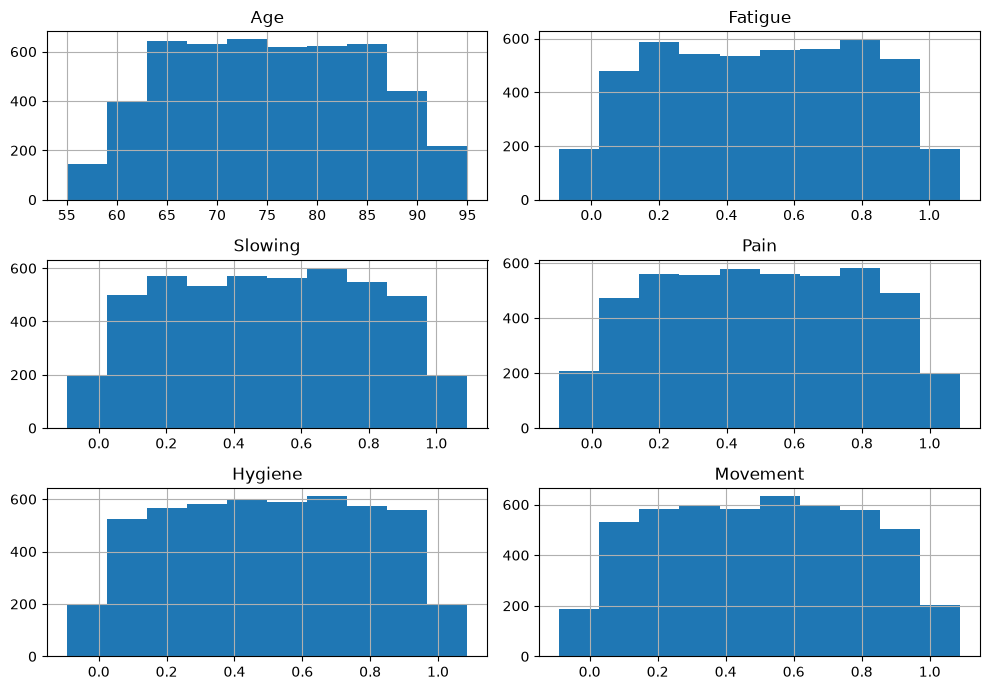

In [72]:
df.hist(figsize=(10, 7))
plt.tight_layout()
plt.show();

<Axes: xlabel='Age', ylabel='Gender'>

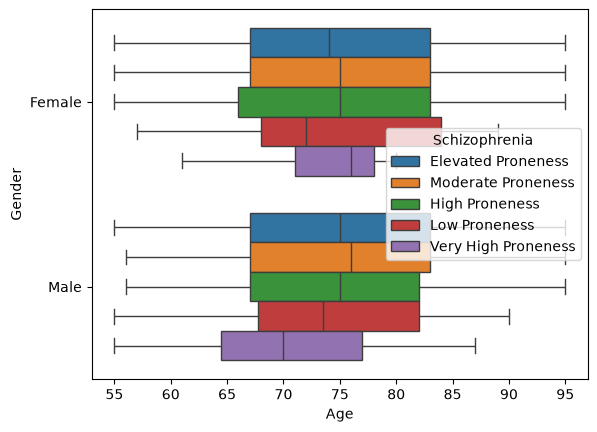

In [73]:
sns.boxplot(data=df, x="Age", y="Gender", hue="Schizophrenia")

<Axes: xlabel='Age'>

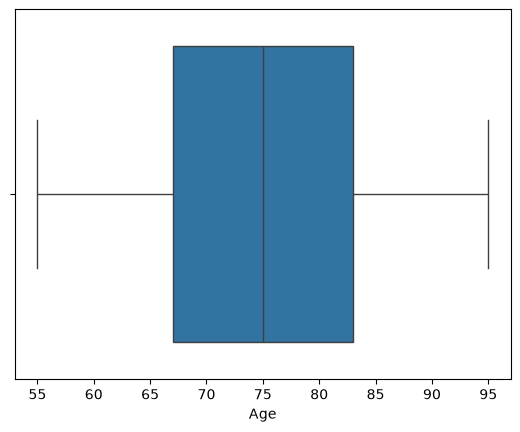

In [74]:
sns.boxplot(x=df["Age"])

<Axes: xlabel='Marital_Status', ylabel='count'>

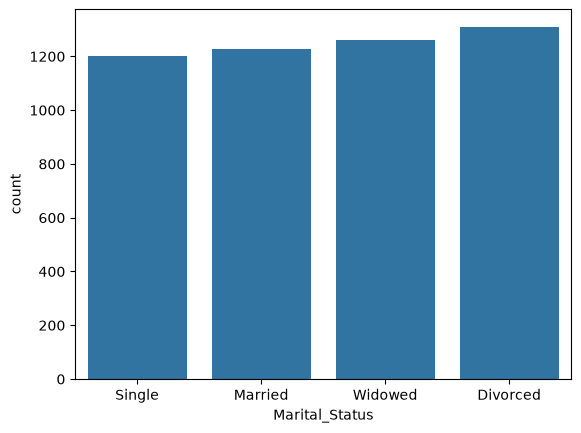

In [75]:
sns.countplot(df, x="Marital_Status")
# THe values here are pretty balanced!

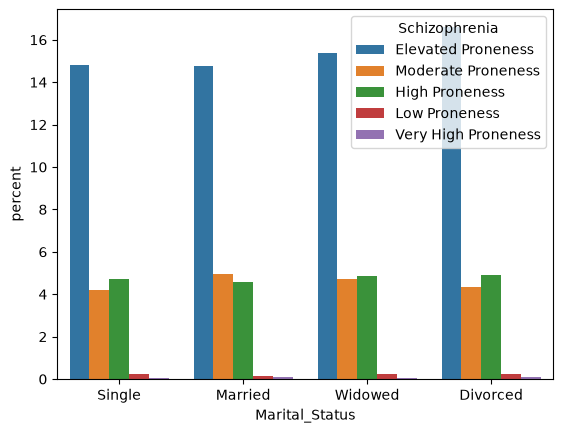

In [76]:
sns.countplot(df, x="Marital_Status", hue="Schizophrenia", stat="percent");

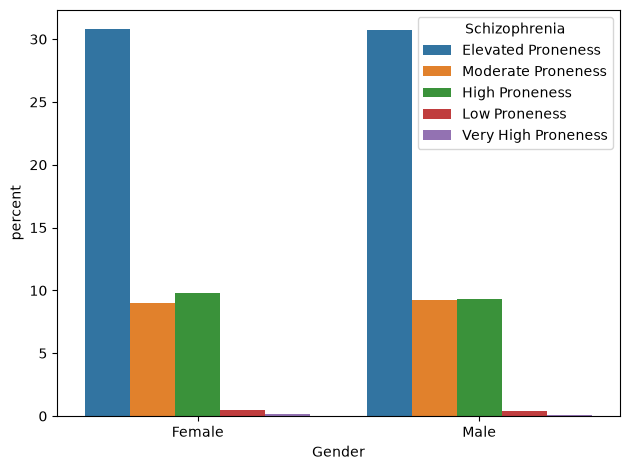

In [77]:
sns.countplot(df, x="Gender", hue="Schizophrenia", stat="percent")
plt.tight_layout()
plt.show();

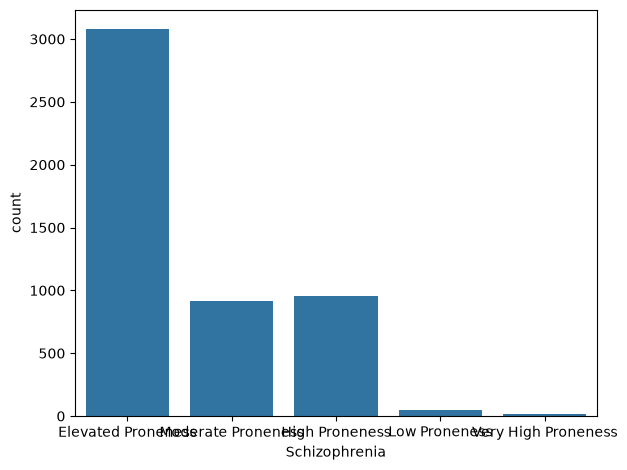

In [78]:
sns.countplot(data=df, x="Schizophrenia")
plt.tight_layout()
plt.show();


<Axes: >

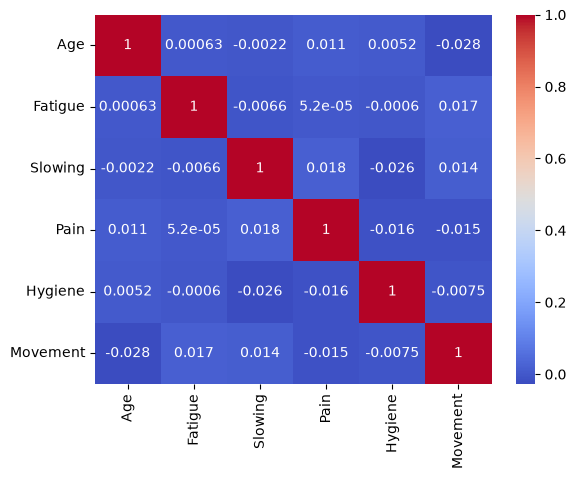

In [79]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

## 5. Split the data

In [80]:
X, y = df.drop("Schizophrenia", axis=1), df["Schizophrenia"]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print(f"the size the of X train: {len(X_train)}")
print(f"the size the of X test: {len(X_test)}")
print(f"the size the of y train: {len(y_train)}")
print(f"the size the of y test: {len(y_test)}")

the size the of X train: 4000
the size the of X test: 1000
the size the of y train: 4000
the size the of y test: 1000


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


# Impute the missing values
impute = SimpleImputer(strategy="mean")

# Get attributes with missing values
attr_for_impute = ['Fatigue', "Slowing", "Pain"]

# Learn the mean from the training data
X_train[attr_for_impute] = impute.fit_transform(X_train[attr_for_impute])


# Use the same mean on the test data
X_test[attr_for_impute] = impute.transform(X_test[attr_for_impute])

print(f"X Train information: {X_train.info()}")

<class 'pandas.DataFrame'>
Index: 4000 entries, 1172 to 1543
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            4000 non-null   str    
 1   Age             4000 non-null   int64  
 2   Gender          4000 non-null   str    
 3   Marital_Status  4000 non-null   str    
 4   Fatigue         4000 non-null   float64
 5   Slowing         4000 non-null   float64
 6   Pain            4000 non-null   float64
 7   Hygiene         4000 non-null   float64
 8   Movement        4000 non-null   float64
dtypes: float64(5), int64(1), str(3)
memory usage: 312.5 KB
X Train information: None


### Drop Name attribute

In [83]:
X_train = X_train.drop("Name", axis=1)
X_test = X_test.drop("Name", axis=1)

X_train

,Age,Gender,Marital_Status,Fatigue,Slowing,Pain,Hygiene,Movement
1172,64,Female,Single,0.069238,0.432709,0.287592,0.276037,0.491355
4367,71,Male,Married,0.610186,0.872438,0.893199,0.869314,0.697132
568,82,Female,Widowed,0.758888,0.432728,0.229185,0.770878,0.672268
1862,68,Male,Divorced,0.343651,0.519455,0.285628,0.976636,0.769338
4664,82,Female,Single,0.345506,0.467318,-0.020327,0.967998,0.199043
...,...,...,...,...,...,...,...,...
199,59,Female,Married,0.682561,0.912891,1.010519,0.858699,0.624353
65,58,Male,Married,0.080171,0.511952,0.496627,0.460934,0.395152
191,76,Male,Widowed,0.034171,0.798239,0.102159,0.938161,0.345230
1911,82,Male,Divorced,0.406915,0.322511,0.527609,0.742768,0.568144


### Use OneHotEncoder

In [91]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Get categories for encoder
attr_encode = ["Gender", "Marital_Status"]

# Encode on the training data
X_train_encoded = encoder.fit_transform(X_train[attr_encode])

# Encode on the testing data
X_test_encoded = encoder.transform(X_test[attr_encode])

In [92]:
import pandas as pd
train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(attr_encode),
    index=X_train.index
)
test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(attr_encode),
    index=X_test.index
)

In [93]:
X_train = X_train.drop(columns=attr_encode)
X_train = pd.concat([X_train, train_encoded], axis=1)

X_test = X_test.drop(columns=attr_encode)
X_test = pd.concat([X_test, test_encoded], axis=1)

In [94]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 4000 entries, 1172 to 1543
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4000 non-null   int64  
 1   Fatigue                  4000 non-null   float64
 2   Slowing                  4000 non-null   float64
 3   Pain                     4000 non-null   float64
 4   Hygiene                  4000 non-null   float64
 5   Movement                 4000 non-null   float64
 6   Gender_Female            4000 non-null   float64
 7   Gender_Male              4000 non-null   float64
 8   Marital_Status_Divorced  4000 non-null   float64
 9   Marital_Status_Married   4000 non-null   float64
 10  Marital_Status_Single    4000 non-null   float64
 11  Marital_Status_Widowed   4000 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 406.2 KB


### Scaler

In [95]:
scaler = StandardScaler()

num_cols = [
    "Age",
    "Fatigue",
    "Slowing",
    "Pain",
    "Hygiene",
    "Movement"
]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [101]:
y_train.value_counts()

Schizophrenia
Elevated Proneness     2462
High Proneness          762
Moderate Proneness      730
Low Proneness            36
Very High Proneness      10
Name: count, dtype: int64

## 6. Train model

In [102]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    y_train
)

In [105]:
y_train_balanced.value_counts()

Schizophrenia
Moderate Proneness     2462
High Proneness         2462
Elevated Proneness     2462
Very High Proneness    2462
Low Proneness          2462
Name: count, dtype: int64

In [106]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, f1_score, accuracy_score, classification_report, confusion_matrix

KNN = KNeighborsClassifier(n_neighbors=5)

KNN.fit(X_train_balanced, y_train_balanced)
y_pred = KNN.predict(X_test)

print(f"Accuracy: \n{accuracy_score(y_test, y_pred) * 100}")
# print(f"Precision: \n{precision_score(y_test, y_pred)}")
# print(f"F1 score: \n{f1_score(y_test, y_pred)}")
print(f"Classification report: \n{classification_report(y_test, y_pred)}")

Accuracy: 
77.60000000000001
Classification report: 
                     precision    recall  f1-score   support

 Elevated Proneness       0.89      0.75      0.82       615
     High Proneness       0.65      0.83      0.73       191
      Low Proneness       0.38      0.33      0.35         9
 Moderate Proneness       0.67      0.83      0.74       182
Very High Proneness       0.00      0.00      0.00         3

           accuracy                           0.78      1000
          macro avg       0.52      0.55      0.53      1000
       weighted avg       0.80      0.78      0.78      1000



In [108]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.892
                     precision    recall  f1-score   support

 Elevated Proneness       0.94      0.90      0.92       615
     High Proneness       0.80      0.90      0.85       191
      Low Proneness       1.00      0.22      0.36         9
 Moderate Proneness       0.84      0.92      0.88       182
Very High Proneness       0.00      0.00      0.00         3

           accuracy                           0.89      1000
          macro avg       0.72      0.59      0.60      1000
       weighted avg       0.89      0.89      0.89      1000



c:\Users\chadi\OneDrive\Desktop\projects\ml-dl-pytorch\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chadi\OneDrive\Desktop\projects\ml-dl-pytorch\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chadi\OneDrive\Desktop\projects\ml-dl-pytorch\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [113]:
from sklearn.svm import SVC

svm = SVC(
    kernel="linear",
    gamma="auto",
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.913
                     precision    recall  f1-score   support

 Elevated Proneness       0.98      0.92      0.95       615
     High Proneness       0.89      0.98      0.93       191
      Low Proneness       0.30      0.89      0.44         9
 Moderate Proneness       0.83      0.84      0.84       182
Very High Proneness       0.67      0.67      0.67         3

           accuracy                           0.91      1000
          macro avg       0.73      0.86      0.77      1000
       weighted avg       0.93      0.91      0.92      1000



In [114]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    SVC(kernel="linear", class_weight="balanced"),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1}
0.7566168180125578
